---

# FINAL EXAM MACHINE LEARNING II

date: "30 April 2025"

author: 
Fernando San Segundo Badahona & Néstor Rodríguez Pérez


---


`fill here your name`


::: {.callout-important icon=false}

No puedes utilizar ChatGPT, pero tienes pleno acceso a Internet y a tus apuntes; no dudes en utilizarlos, ya que sueles ser mucho más útil para programar, mirar documentación o resolver errores de código.
:::

::: {.callout-warning icon=false}

**Evita dedicar tiempo a generar código o gráficas no solicitadas.**

No se evaluarán y sólo servirán para consumir tiempo del examen.
:::

In [2]:
%cd Final2425

[WinError 2] El sistema no puede encontrar el archivo especificado: 'Final2425'
c:\Users\nrodriguezp\OneDrive - Universidad Pontificia Comillas\Documentos\github\machine_learning_2526\MLMIIN\Final2425


# **Synthetic GDPR dataset** (6 points)

Context: Although this dataset has been artificially made for this problem, we will assume that each observation in the dataset contains personal information. It contains 827 observations with 5 features each (X1, X2, X4, X4, X5) and a label assigned.

The objective of the following questions is to apply unsupervised learning techniques to this dataset, to see if we can apply them to label new future observations.

**You DO NOT need to carry out a full EDA (delete NaNs, delete outliers, pairplot etc.) as you did with the Classification assignment**

For your convenience, we import in the next cell some of the libraries for unsupervised learning we have seen in the course

In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering

In [4]:
df= pd.read_csv('gdpr_data.csv')



::: {.callout-tip icon="false}
### Question 0 : PCA (1.5 points)



* Perform PCA on the data.
* Based on it, indicate which features are the most important for the model, any correlations between features
* How many principal components you would keep in order to explain more than 90% of the variance of the data?
* You can use these principal components for the rest of the questions.

:::

In [5]:
feature_columns = [col for col in df.columns if col.startswith('X')]
X = df[feature_columns].values
true_labels = df['label'].values

X

array([[ 1.40471903, -2.62073282, -0.09069565,  1.8966345 ,  5.34430218],
       [ 1.09995212, -0.80498562,  0.42230899,  1.14730125,  4.69057595],
       [ 1.00168533, -1.47395654,  1.09513305,  2.44483341,  6.21807031],
       ...,
       [ 2.24310582, -4.21835617,  3.76219627,  5.22693773, 19.55012087],
       [ 2.28569979, -1.49659933,  3.00755957,  4.9800308 , 15.20675291],
       [-1.85889492,  4.04591704,  4.5566364 , -5.20955991, -4.93408711]])

     Exp_variance  cum_Exp_variance
PC1      0.553998          0.553998
PC2      0.394897          0.948896
PC3      0.036094          0.984990
PC4      0.012804          0.997795
PC5      0.002205          1.000000


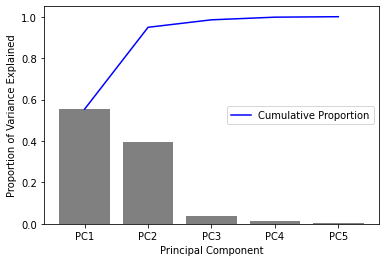

In [6]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)
exp_variance = pd.DataFrame(data=pca.explained_variance_ratio_,
                            index=['PC' + str(n_pca + 1) for n_pca in range(pca.n_components)],
                            columns=['Exp_variance'])
exp_variance['cum_Exp_variance'] = exp_variance['Exp_variance'].cumsum()

print(exp_variance)

sns.barplot(data=exp_variance, x=exp_variance.index, y='Exp_variance', color='gray')
sns.lineplot(data=exp_variance, x=exp_variance.index, y='cum_Exp_variance', color='blue', label='Cumulative Proportion')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Component')
plt.legend()
plt.show()

In [7]:
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_), columns=['PC' + str(pca + 1) for pca in range(pca.n_components)])
loadings

,PC1,PC2,PC3,PC4,PC5
0,0.724935,0.604654,-0.329784,0.035693,0.006468
1,-0.972020,-0.100001,-0.107624,0.184862,-0.025089
2,-0.910887,0.399429,-0.054445,-0.052982,0.078622
3,0.334927,0.904395,0.239426,0.116616,0.013452
4,-0.600917,0.789809,-0.007782,-0.110659,-0.063293


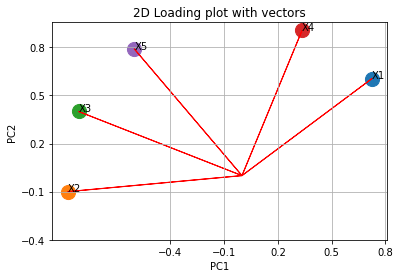

In [8]:
# Get the loadings of x and y axes
xs = loadings['PC1']
ys = loadings['PC2']

# Plot the loadings on a scatterplot
for i, varnames in enumerate(feature_columns):
    plt.scatter(xs.iloc[i], ys.iloc[i], s=200)
    plt.arrow(
        0, 0, # coordinates of arrow base
        xs.iloc[i], # length of the arrow along x
        ys.iloc[i], # length of the arrow along y
        color='r',
        head_width=0
        )
    plt.text(xs.iloc[i], ys.iloc[i], varnames)

# Define the axes
xticks = np.linspace(-0.4, 0.8, num=5)
yticks = np.linspace(-0.4, 0.8, num=5)
plt.xticks(xticks)
plt.yticks(yticks)
plt.xlabel('PC1')
plt.ylabel('PC2')

# Show plot
plt.title('2D Loading plot with vectors')
plt.grid()
plt.show()


::: {.callout-tip icon="false}
### Question 1 : KMEANS (1 points)

* Apply **KMEANS** clustering to the dataset.
* You have to **justify the number of clusters** you choose.
* You **cannot** justify it by looking at the labels of the dataset: if you do so, your mark for this question will be 0.
* **Visualize the clusters in a 2D plot.**
:::

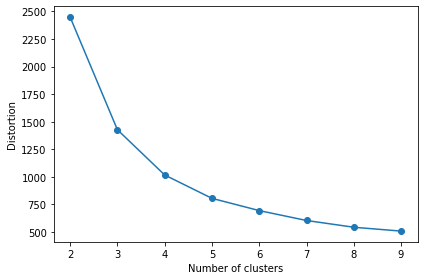

In [9]:
distortions = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, n_init=10, random_state=42)
    km.fit(X_pca)
    distortions.append(km.inertia_)

plt.plot(range(2,10), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

Por el gráfico, podría elegir 4 o 5 clusters

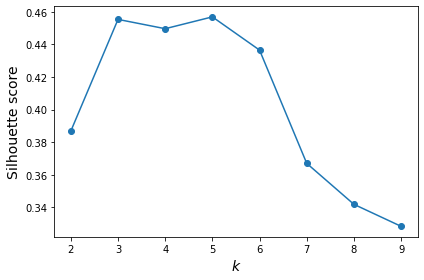

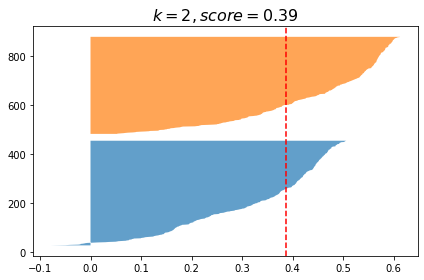

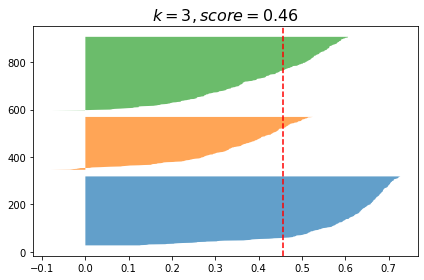

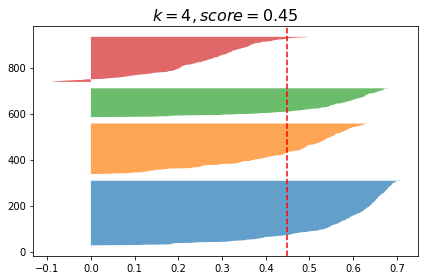

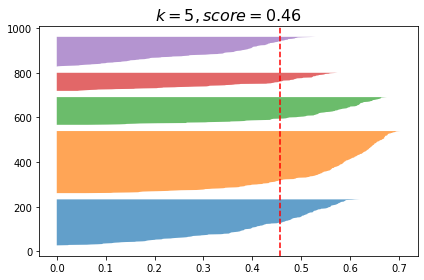

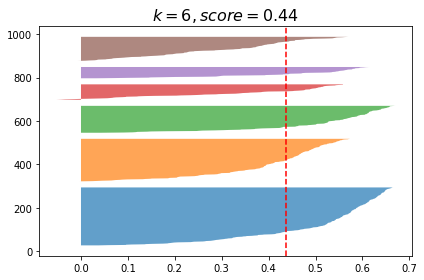

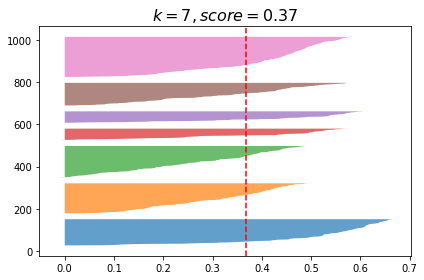

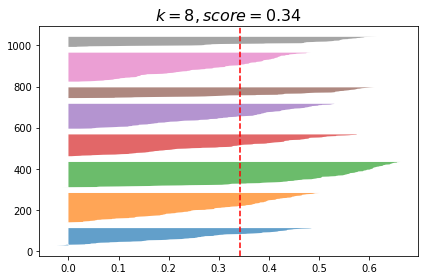

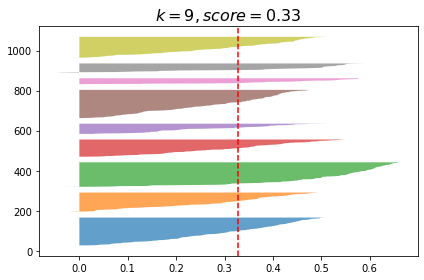

In [10]:
from sklearn.metrics import silhouette_samples
from sklearn.metrics import silhouette_score
from matplotlib.ticker import FixedLocator, FixedFormatter
import warnings
Ks = range(2, 10)
warnings.filterwarnings("ignore")
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X_pca) for k in Ks]
silhouette_scores = [silhouette_score(X_pca, model.labels_) for model in kmeans_per_k]

plt.figure()
plt.plot(Ks, silhouette_scores, marker='o')
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.tight_layout()
plt.show()

def plot_silhouette(model, X):
    mu = model.cluster_centers_
    K, D = mu.shape
    y_pred = model.labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)
    silhouette_scores = silhouette_score(X, model.labels_)
    padding = len(X) // 30
    pos = padding
    for i in range(K):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        # color = colors[i]
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs, alpha=0.7)
        pos += len(coeffs) + padding
    score = silhouette_scores
    plt.axvline(x=score, color="red", linestyle="--")
    plt.title("$k={}, score={:0.2f}$".format(K, score), fontsize=16)


for model in kmeans_per_k:
    K, D = model.cluster_centers_.shape
    plt.figure()
    plot_silhouette(model, X_pca)
    fname = f"kmeans_silhouette_diagram{K}.pdf"
    plt.tight_layout()

En el score the silhoutte también vemos que podríamos coger 5 clusters

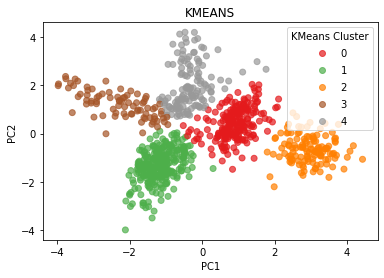

In [11]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, n_init = 10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='Set1', alpha=0.7)
plt.title('KMEANS')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title="KMeans Cluster")


::: {.callout-tip icon="false}
### Question 2 : AGGLOMERATIVE CLUSTERING (1 point)

* Apply **Agglomerative clustering** to the dataset.
* **Justify the number of clusters** you would choose based on the results of the Agglomerative clustering.
* **Visualize the clusters in a 2D plot.**
:::

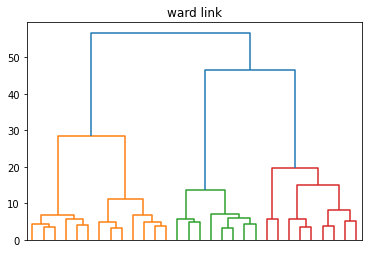

In [12]:
#agglo = AgglomerativeClustering(n_clusters=n_clusters)
import scipy
from scipy.spatial.distance import pdist

agglo = AgglomerativeClustering(linkage='ward').fit(X_pca)
cityDist = pdist(X_pca, 'euclidean')
agglo_labels = agglo.fit_predict(X_pca)

plt.figure()
Z = scipy.cluster.hierarchy.linkage(cityDist, method='ward')
scipy.cluster.hierarchy.dendrogram(Z, truncate_mode='lastp')
plt.title('ward link')
plt.tick_params(labelbottom=False)
plt.show()

4 clusters parece razonable basandonos en el dendrograma

In [13]:
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(X_pca)

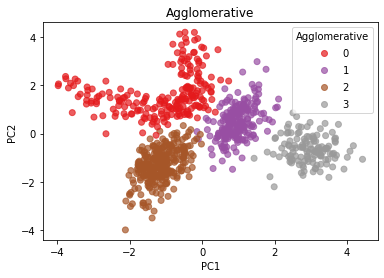

In [14]:
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='Set1', alpha=0.7)
plt.title('Agglomerative')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title="Agglomerative")


::: {.callout-tip icon="false}
### Question 3 : DBSCAN and GMM (1.5 points)

* Apply **GMM** clustering to the dataset. Indicate to GMM the number of clusters you best consider based on the results of previous questions.
* Apply **DBSCAN** clustering to the dataset. Discuss the difficulties you may have found in the adjustment of the model.
* Visualize the clusters of DBSCAN and GMM in separate 2D plots.
:::

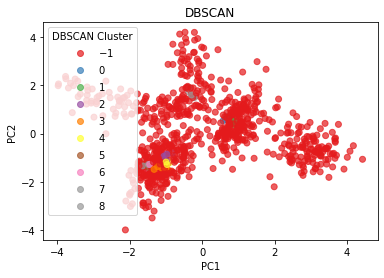

In [15]:
dbscan = DBSCAN(eps=0.2, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_pca)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='Set1', alpha=0.7)
plt.title('DBSCAN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title="DBSCAN Cluster")

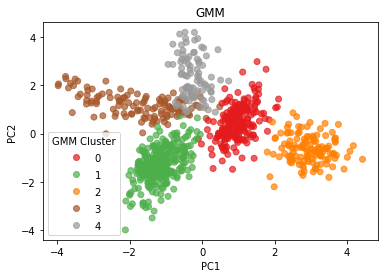

In [16]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='Set1', alpha=0.7)
plt.title('GMM')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title="GMM Cluster")


::: {.callout-tip icon="false}
### Question 4: Comparison against the real labels and conclusions for clustering (1 point)

* Use the adjusted Rand Index to compare the results of each of the clustering techniques you have applied in previous questions **with respect to the real labels** of the dataset.
* Compare again the different clustering methods (except for DBSCAN), but this time, use K=4 clusters.
* Indicate conclusions for the different clustering techniques. Indicate which one you would use to cluster new observations.
:::

In [17]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index (KMEANS): {ari:.3f}")
ari_dbscan = adjusted_rand_score(true_labels, dbscan_labels)
print(f"Adjusted Rand Index (DBSCAN): {ari_dbscan:.3f}")
ari_gmm = adjusted_rand_score(true_labels, gmm_labels)
print(f"Adjusted Rand Index (GMM): {ari_gmm:.3f}")
ari_agglo = adjusted_rand_score(true_labels, agglo_labels)
print(f"Adjusted Rand Index (Agglomerative): {ari_agglo:.3f}")

Adjusted Rand Index (KMEANS): 0.856
Adjusted Rand Index (DBSCAN): -0.012
Adjusted Rand Index (GMM): 0.892
Adjusted Rand Index (Agglomerative): 0.969


In [20]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, n_init = 10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

agglo = AgglomerativeClustering(linkage='ward', n_clusters=n_clusters).fit(X_pca)
agglo_labels = agglo.fit_predict(X_pca)

ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index (KMEANS): {ari:.3f}")
ari_dbscan = adjusted_rand_score(true_labels, dbscan_labels)
print(f"Adjusted Rand Index (DBSCAN): {ari_dbscan:.3f}")
ari_gmm = adjusted_rand_score(true_labels, gmm_labels)
print(f"Adjusted Rand Index (GMM): {ari_gmm:.3f}")
ari_agglo = adjusted_rand_score(true_labels, agglo_labels)
print(f"Adjusted Rand Index (Agglomerative): {ari_agglo:.3f}")

Adjusted Rand Index (KMEANS): 0.893
Adjusted Rand Index (DBSCAN): -0.012
Adjusted Rand Index (GMM): 0.953
Adjusted Rand Index (Agglomerative): 0.969



::: {.callout-tip icon="false}
### (OPTIONAL) Question 5: Dataset for classification (1 point)

* Due to privacy concerns, we cannot use the original dataset to train a supervised classification model. We need to create a new dataset with the same features but without the labels. Apply density estimation to obtain a model that allows us to generate new observations with the same distribution as the original dataset.
* Generate 1000 new observations with the same distribution as the original dataset. **Justify the number of components you choose for the density estimation based on AIC and BIC.**
* To assign the labels to the new observations, use the GMM model (K=4) that you have developed previously.
* Visualize the new dataset with scatterplot
:::

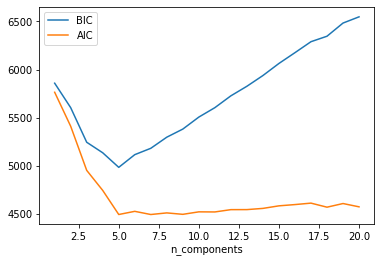

In [21]:
n_components = np.arange(1, 21)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X_pca)
          for n in n_components]

plt.plot(n_components, [m.bic(X_pca) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X_pca) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

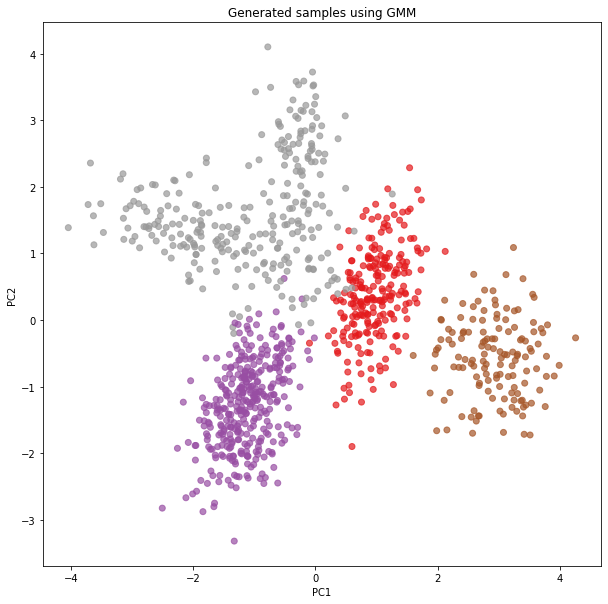

In [22]:
gmm_2 = GaussianMixture(n_components=5, random_state=42)
gmm_2.fit(X_pca)
generated = gmm_2.sample(n_samples=1000)
X_generated = generated[0]

# Assign labels to the generated data using the clustering model chosen in the previous question
X_generated_labels = gmm.predict(X_generated)

# visualize
plt.figure(figsize=(10, 10))
plt.scatter(X_generated[:, 0], X_generated[:, 1],c=X_generated_labels, cmap='Set1', alpha=0.7)
plt.title('Generated samples using GMM')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()